Creating Spearman heatmap for waves for RQ3

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [ ]:

waves = ["early", "delta", "omicron"]

# load full feature importance csv of each wave
importance_wave = {}

for wave in waves:

    wave_importance_dataset = pd.read_csv(f"RQ3_facemask_{wave}_RF_FeatureImportance_rolling.csv")

    importance_wave[wave] = wave_importance_dataset.set_index("Feature")["Importance"]





# combine into one dataframe
# rows = features   columns = waves

importance_matrix = pd.DataFrame(importance_wave)


print(importance_matrix.shape)  
print(importance_matrix.head())

print(f"\n any NAs: ", importance_matrix.isna().sum())


(61, 3)
                                             early     delta   omicron
Feature                                                               
7days_rolling_cases                       0.101581  0.176855  0.193267
7days_rolling_deaths                      0.145896  0.077687  0.148812
Can't control worrying_Nearly every day   0.002455  0.000708  0.001446
Can't control worrying_Not at all         0.003834  0.001196  0.003304
Can't control worrying_Prefer not to say  0.000943  0.000053  0.000770

 any NAs:  early      0
delta      0
omicron    0
dtype: int64


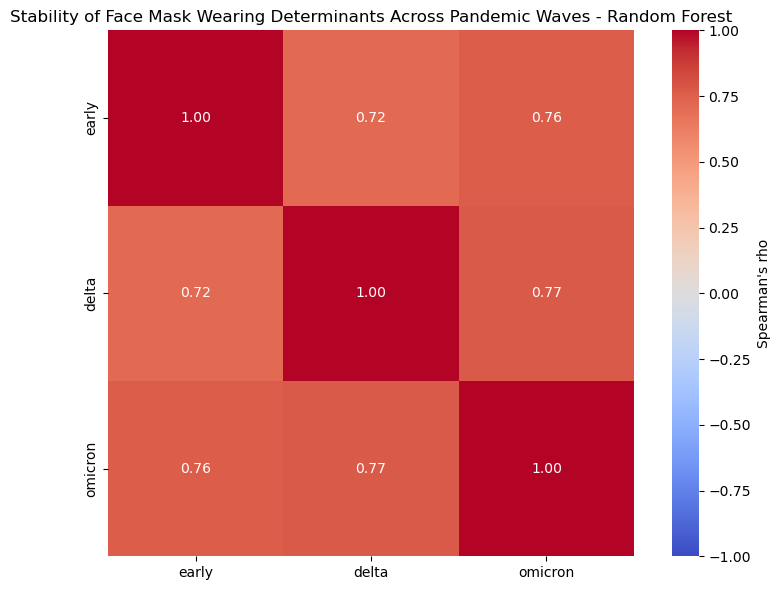

In [3]:
# Spearman correlation between waves
rho_matrix = pd.DataFrame(index=waves, columns=waves, dtype=float)
pval_matrix = pd.DataFrame(index=waves, columns=waves, dtype=float)

for wave1 in waves:
    for wave2 in waves:
        rho, pval = spearmanr(importance_matrix[wave1], importance_matrix[wave2])
        # rho = spearmanr(importance_matrix[state1], importance_matrix[state2])
        rho_matrix.loc[wave1, wave2] = rho
        pval_matrix.loc[wave1, wave2] = pval





# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(rho_matrix.astype(float), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Spearman's rho"})
plt.title("Stability of Face Mask Wearing Determinants Across Pandemic Waves - Random Forest")
plt.tight_layout()
plt.savefig("RQ3_facemask_RF_SpearmanHeatmap_rolling.png", dpi=300, bbox_inches="tight")
plt.show()

rho_matrix.to_csv("RQ3_facemask_RF_SpearmanRho_rolling.csv")
# pval_matrix.to_csv("RQ2_facemask_RF_SpearmanPval.csv")